In [13]:
!pip install -q openai-whisper gradio librosa pandas numpy nltk textblob scikit-learn matplotlib wordcloud

In [14]:
!apt-get -qq install ffmpeg

In [15]:
import whisper
import librosa
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from google.colab import files

nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [16]:
model = whisper.load_model("base")

print("Whisper model loaded successfully!")

Whisper model loaded successfully!


In [17]:
uploaded = files.upload()

audio_file = list(uploaded.keys())[0]

print("Uploaded file:", audio_file)

Saving app11.m4a to app11.m4a
Uploaded file: app11.m4a


In [18]:
result = model.transcribe(audio_file)

transcript = result["text"]

print("Survey Response:")
print(transcript)

/usr/local/lib/python3.13/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Survey Response:
 The college library is useful, but there are not enough books. The computers are also sometimes small. I would like the college to improve the library facilities.


In [19]:
audio, sr = librosa.load(audio_file, sr=None)

duration = librosa.get_duration(y=audio, sr=sr)

word_count = len(transcript.split())

wpm = (word_count / duration) * 60 if duration > 0 else 0

print("Duration:", round(duration, 2), "seconds")
print("Word Count:", word_count)
print("Speaking Rate:", round(wpm, 2), "words/minute")

/tmp/ipykernel_1080/3396254271.py:1: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_file, sr=None)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Duration: 12.86 seconds
Word Count: 27
Speaking Rate: 125.93 words/minute


In [20]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

cleaned_text = clean_text(transcript)

print(cleaned_text)

the college library is useful but there are not enough books the computers are also sometimes small i would like the college to improve the library facilities


In [21]:
categories = {
    "Library": [
        "library", "book", "books", "reading", "computer", "computers"
    ],

    "Teaching": [
        "teacher", "teaching", "faculty", "professor", "class", "lecture"
    ],

    "Infrastructure": [
        "building", "classroom", "lab", "laboratory", "facility", "facilities"
    ],

    "Transportation": [
        "bus", "transport", "travel", "vehicle", "road"
    ],

    "Food": [
        "food", "canteen", "cafeteria", "lunch", "meal"
    ],

    "Technology": [
        "internet", "wifi", "software", "computer", "website", "technology"
    ],

    "Student Services": [
        "office", "service", "support", "registration", "help"
    ]
}

In [22]:
def detect_category(text):
    text = text.lower()

    scores = {}

    for category, keywords in categories.items():
        score = sum(1 for keyword in keywords if keyword in text)
        scores[category] = score

    best_category = max(scores, key=scores.get)

    if scores[best_category] == 0:
        return "General"

    return best_category

In [23]:
category = detect_category(cleaned_text)

print("Detected Category:", category)

Detected Category: Library


In [24]:
def analyze_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0.1:
        sentiment = "Positive"
    elif polarity < -0.1:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"

    return sentiment, polarity

In [25]:
sentiment, polarity = analyze_sentiment(transcript)

print("Sentiment:", sentiment)
print("Polarity:", round(polarity, 3))

Sentiment: Neutral
Polarity: 0.017


In [26]:
stop_words = set(stopwords.words("english"))

def extract_keywords(text, top_n=8):

    words = re.findall(r'\b[a-zA-Z]{3,}\b', text.lower())

    words = [
        word for word in words
        if word not in stop_words
    ]

    if not words:
        return []

    vectorizer = TfidfVectorizer()

    try:
        matrix = vectorizer.fit_transform([" ".join(words)])
        scores = matrix.toarray()[0]
        terms = vectorizer.get_feature_names_out()

        ranked = sorted(
            zip(terms, scores),
            key=lambda x: x[1],
            reverse=True
        )

        return [word for word, score in ranked[:top_n]]

    except:
        return list(dict.fromkeys(words))[:top_n]

In [27]:
keywords = extract_keywords(transcript)

print("Important Keywords:")
print(keywords)

Important Keywords:
['college', 'library', 'also', 'books', 'computers', 'enough', 'facilities', 'improve']


In [28]:
def detect_response_type(text):

    text = text.lower()

    improvement_words = [
        "improve", "better", "increase", "change",
        "provide", "upgrade", "need", "should"
    ]

    complaint_words = [
        "problem", "issue", "poor", "bad",
        "slow", "not working", "difficult"
    ]

    appreciation_words = [
        "good", "great", "excellent",
        "useful", "helpful", "satisfied"
    ]

    improvement_score = sum(
        word in text for word in improvement_words
    )

    complaint_score = sum(
        word in text for word in complaint_words
    )

    appreciation_score = sum(
        word in text for word in appreciation_words
    )

    scores = {
        "Improvement Suggestion": improvement_score,
        "Complaint": complaint_score,
        "Appreciation": appreciation_score
    }

    best = max(scores, key=scores.get)

    if scores[best] == 0:
        return "General Feedback"

    return best

In [29]:
response_type = detect_response_type(transcript)

print("Response Type:", response_type)

Response Type: Improvement Suggestion


In [30]:
survey_result = {
    "Transcript": transcript,
    "Category": category,
    "Sentiment": sentiment,
    "Polarity": round(polarity, 3),
    "Response Type": response_type,
    "Keywords": ", ".join(keywords),
    "Duration (sec)": round(duration, 2),
    "Word Count": word_count,
    "Speaking Rate (WPM)": round(wpm, 2)
}

survey_result

{'Transcript': ' The college library is useful, but there are not enough books. The computers are also sometimes small. I would like the college to improve the library facilities.',
 'Category': 'Library',
 'Sentiment': 'Neutral',
 'Polarity': 0.017,
 'Response Type': 'Improvement Suggestion',
 'Keywords': 'college, library, also, books, computers, enough, facilities, improve',
 'Duration (sec)': 12.86,
 'Word Count': 27,
 'Speaking Rate (WPM)': 125.93}

In [31]:
survey_df = pd.DataFrame([survey_result])

survey_df

,Transcript,Category,Sentiment,Polarity,Response Type,Keywords,Duration (sec),Word Count,Speaking Rate (WPM)
0,"The college library is useful, but there are ...",Library,Neutral,0.017,Improvement Suggestion,"college, library, also, books, computers, enou...",12.86,27,125.93


In [32]:
survey_df.to_csv(
    "survey_analysis.csv",
    index=False
)

print("survey_analysis.csv created successfully!")

survey_analysis.csv created successfully!


In [33]:
sample_data = {
    "Response": [
        "The library has useful books but needs more computers.",
        "The teachers explain concepts very clearly.",
        "The college bus is often late.",
        "The canteen food needs improvement.",
        "The internet connection is very good.",
        "The classrooms need better facilities.",
        "The student support office is very helpful.",
        "The library should provide more reference books.",
        "The laboratory computers are slow.",
        "The teaching quality is excellent."
    ]
}

sample_df = pd.DataFrame(sample_data)

sample_df

,Response
0,The library has useful books but needs more co...
1,The teachers explain concepts very clearly.
2,The college bus is often late.
3,The canteen food needs improvement.
4,The internet connection is very good.
5,The classrooms need better facilities.
6,The student support office is very helpful.
7,The library should provide more reference books.
8,The laboratory computers are slow.
9,The teaching quality is excellent.


In [34]:
def analyze_response(text):

    category = detect_category(text)
    sentiment, polarity = analyze_sentiment(text)
    response_type = detect_response_type(text)
    keywords = extract_keywords(text)

    return {
        "Response": text,
        "Category": category,
        "Sentiment": sentiment,
        "Polarity": round(polarity, 3),
        "Response Type": response_type,
        "Keywords": ", ".join(keywords)
    }

results = [
    analyze_response(text)
    for text in sample_df["Response"]
]

analysis_df = pd.DataFrame(results)

analysis_df

,Response,Category,Sentiment,Polarity,Response Type,Keywords
0,The library has useful books but needs more co...,Library,Positive,0.40,Improvement Suggestion,"books, computers, library, needs, useful"
1,The teachers explain concepts very clearly.,Teaching,Positive,0.13,General Feedback,"clearly, concepts, explain, teachers"
2,The college bus is often late.,Transportation,Negative,-0.30,General Feedback,"bus, college, late, often"
3,The canteen food needs improvement.,Food,Neutral,0.00,Improvement Suggestion,"canteen, food, improvement, needs"
4,The internet connection is very good.,Technology,Positive,0.91,Appreciation,"connection, good, internet"
5,The classrooms need better facilities.,Infrastructure,Positive,0.50,Improvement Suggestion,"better, classrooms, facilities, need"
6,The student support office is very helpful.,Student Services,Positive,0.20,Appreciation,"helpful, office, student, support"
7,The library should provide more reference books.,Library,Positive,0.50,Improvement Suggestion,"books, library, provide, reference"
8,The laboratory computers are slow.,Library,Negative,-0.30,Complaint,"computers, laboratory, slow"
9,The teaching quality is excellent.,Teaching,Positive,1.00,Appreciation,"excellent, quality, teaching"


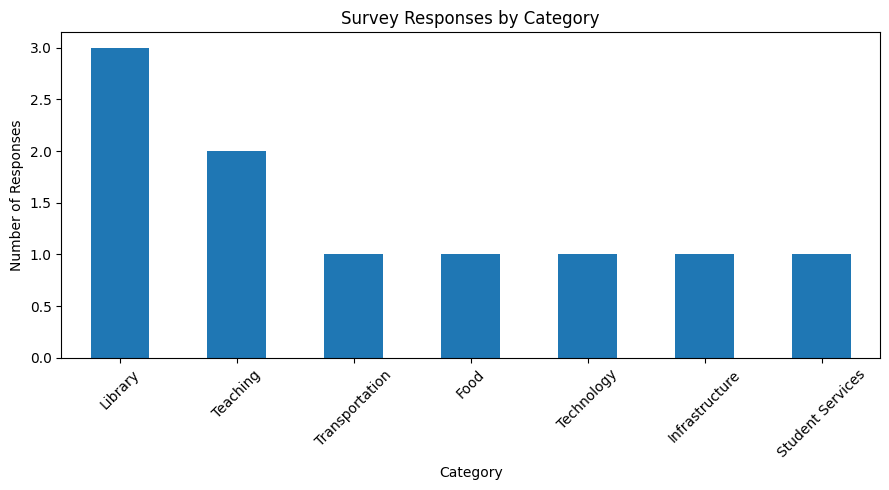

In [35]:
category_counts = analysis_df["Category"].value_counts()

plt.figure(figsize=(9, 5))

category_counts.plot(kind="bar")

plt.title("Survey Responses by Category")
plt.xlabel("Category")
plt.ylabel("Number of Responses")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("category_distribution.png")

plt.show()

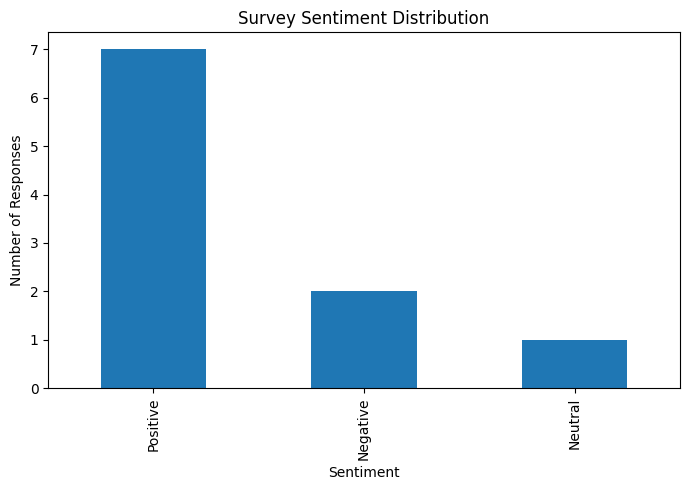

In [36]:
sentiment_counts = analysis_df["Sentiment"].value_counts()

plt.figure(figsize=(7, 5))

sentiment_counts.plot(kind="bar")

plt.title("Survey Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Responses")

plt.tight_layout()

plt.savefig("sentiment_distribution.png")

plt.show()

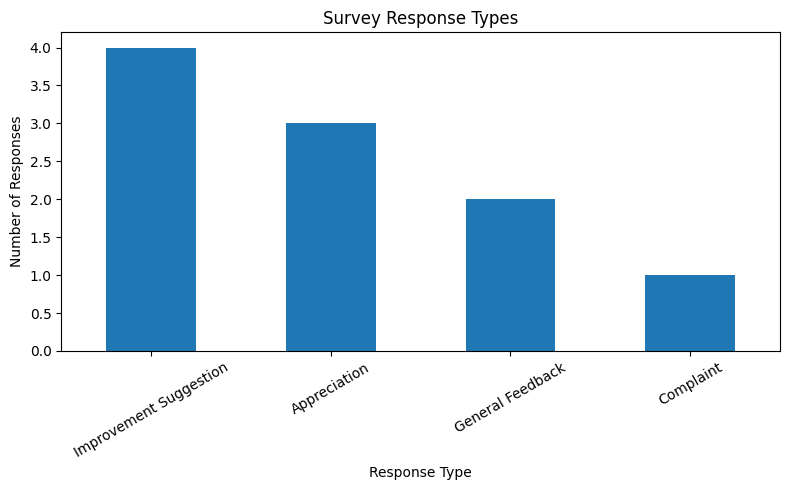

In [37]:
response_type_counts = analysis_df["Response Type"].value_counts()

plt.figure(figsize=(8, 5))

response_type_counts.plot(kind="bar")

plt.title("Survey Response Types")
plt.xlabel("Response Type")
plt.ylabel("Number of Responses")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

In [38]:
print("========== SURVEY INSIGHTS ==========")

print("\nTotal Responses:", len(analysis_df))

print(
    "\nMost Common Category:",
    analysis_df["Category"].mode()[0]
)

print(
    "Most Common Sentiment:",
    analysis_df["Sentiment"].mode()[0]
)

print(
    "Most Common Response Type:",
    analysis_df["Response Type"].mode()[0]
)

print("\nCategory Distribution:")
print(category_counts)

print("\nSentiment Distribution:")
print(sentiment_counts)

========== SURVEY INSIGHTS ==========

Total Responses: 10

Most Common Category: Library
Most Common Sentiment: Positive
Most Common Response Type: Improvement Suggestion

Category Distribution:
Category
Library             3
Teaching            2
Transportation      1
Food                1
Technology          1
Infrastructure      1
Student Services    1
Name: count, dtype: int64

Sentiment Distribution:
Sentiment
Positive    7
Negative    2
Neutral     1
Name: count, dtype: int64


In [39]:
analysis_df.to_csv(
    "survey_responses.csv",
    index=False
)

print("survey_responses.csv saved!")

survey_responses.csv saved!


In [40]:
import gradio as gr

In [41]:
def voice_survey_analyzer(audio_path):

    if audio_path is None:
        return "Please upload a voice recording.", "", ""

    result = model.transcribe(audio_path)

    transcript = result["text"]

    cleaned = clean_text(transcript)

    category = detect_category(cleaned)

    sentiment, polarity = analyze_sentiment(transcript)

    response_type = detect_response_type(transcript)

    keywords = extract_keywords(transcript)

    audio, sr = librosa.load(audio_path, sr=None)

    duration = librosa.get_duration(
        y=audio,
        sr=sr
    )

    word_count = len(transcript.split())

    wpm = (
        word_count / duration * 60
        if duration > 0 else 0
    )

    summary = f"""
Category: {category}

Sentiment: {sentiment}

Sentiment Score: {round(polarity, 3)}

Response Type: {response_type}

Important Keywords: {", ".join(keywords)}

Duration: {round(duration, 2)} seconds

Word Count: {word_count}

Speaking Rate: {round(wpm, 2)} WPM
"""

    return transcript, summary, ", ".join(keywords)

In [42]:
demo = gr.Interface(
    fn=voice_survey_analyzer,

    inputs=gr.Audio(
        type="filepath",
        label="🎙️ Upload Survey Response"
    ),

    outputs=[
        gr.Textbox(
            label="📝 Transcript",
            lines=8
        ),

        gr.Textbox(
            label="📊 Survey Analysis",
            lines=12
        ),

        gr.Textbox(
            label="🔑 Important Keywords",
            lines=3
        )
    ],

    title="🎙️ VoiceSurvey – Spoken Survey Analyzer",

    description=(
        "Upload a spoken survey response to automatically "
        "extract categories, sentiment, response type, "
        "keywords and survey insights."
    )
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://68e137c4492463869a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [43]:
requirements = """openai-whisper
gradio
librosa
pandas
numpy
nltk
textblob
scikit-learn
matplotlib
wordcloud
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created!")

requirements.txt created!


In [44]:
import os

print("Project Files:")

for file in os.listdir():
    if file.endswith((".csv", ".png", ".md", ".txt", ".ipynb")):
        print(file)

Project Files:
survey_analysis.csv
survey_responses.csv
requirements.txt
category_distribution.png
sentiment_distribution.png
